In [1]:
from collections import deque
import math
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

from sdk_client import Robot

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.grid'] = True

rob = Robot("eth0")


def _quat_to_rpy(quat):
    if quat is None or len(quat) < 4:
        return None
    try:
        x, y, z, w = [float(v) for v in quat[:4]]
    except Exception:
        return None
    sinr_cosp = 2.0 * (w * x + y * z)
    cosr_cosp = 1.0 - 2.0 * (x * x + y * y)
    roll = math.atan2(sinr_cosp, cosr_cosp)
    sinp = 2.0 * (w * y - z * x)
    if abs(sinp) >= 1.0:
        pitch = math.copysign(math.pi / 2.0, sinp)
    else:
        pitch = math.asin(sinp)
    siny_cosp = 2.0 * (w * z + x * y)
    cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
    yaw = math.atan2(siny_cosp, cosy_cosp)
    return (roll, pitch, yaw)


def _safe_vec3(value):
    if value is None:
        return None
    try:
        if isinstance(value, (list, tuple)) and len(value) >= 3:
            return tuple(float(value[i]) for i in range(3))
        keys = ("x", "y", "z")
        if all(hasattr(value, key) for key in keys):
            return tuple(float(getattr(value, key)) for key in keys)
    except Exception:
        return None
    return None


def _extract_crotch_imu(msg):
    if msg is None:
        return {
            "rpy": None,
            "gyro": None,
            "acc": None,
            "quat": None,
        }
    quat = None
    for path in (("orientation",), ("imu_state", "quaternion"), ("quaternion",)):
        cur = msg
        ok = True
        for key in path:
            if cur is None or not hasattr(cur, key):
                ok = False
                break
            cur = getattr(cur, key)
        if not ok:
            continue
        if hasattr(cur, "x") and hasattr(cur, "y") and hasattr(cur, "z") and hasattr(cur, "w"):
            quat = (float(cur.x), float(cur.y), float(cur.z), float(cur.w))
            break
        if isinstance(cur, (list, tuple)) and len(cur) >= 4:
            quat = tuple(float(cur[i]) for i in range(4))
            break
    gyro = _safe_vec3(getattr(msg, "angular_velocity", None))
    if gyro is None:
        gyro = _safe_vec3(getattr(msg, "gyroscope", None))
    acc = _safe_vec3(getattr(msg, "linear_acceleration", None))
    if acc is None:
        acc = _safe_vec3(getattr(msg, "accelerometer", None))
    return {
        "rpy": _quat_to_rpy(quat),
        "gyro": gyro,
        "acc": acc,
        "quat": quat,
    }


print("Robot ready:", rob)
print("Run the next cells and interrupt a cell to stop its live view.")


Robot ready: <sdk_client.Robot object at 0xffff95bfbc10>
Run the next cells and interrupt a cell to stop its live view.


In [2]:
history_len = 200
times = deque(maxlen=history_len)

body_rpy_hist = {axis: deque(maxlen=history_len) for axis in "rpy"}
body_gyro_hist = {axis: deque(maxlen=history_len) for axis in "xyz"}
body_acc_hist = {axis: deque(maxlen=history_len) for axis in "xyz"}

crotch_rpy_hist = {axis: deque(maxlen=history_len) for axis in "rpy"}
crotch_gyro_hist = {axis: deque(maxlen=history_len) for axis in "xyz"}
crotch_acc_hist = {axis: deque(maxlen=history_len) for axis in "xyz"}

start_t = time.time()

while True:
    body = rob.get_imu()
    crotch = _extract_crotch_imu(rob.get_lidar_imu())
    t = time.time() - start_t
    times.append(t)

    body_rpy = body.rpy if body is not None else None
    body_gyro = body.gyro if body is not None else None
    body_acc = body.acc if body is not None else None

    for idx, axis in enumerate("rpy"):
        body_rpy_hist[axis].append(np.nan if body_rpy is None else float(body_rpy[idx]))
        crotch_rpy_hist[axis].append(np.nan if crotch["rpy"] is None else float(crotch["rpy"][idx]))
    for idx, axis in enumerate("xyz"):
        body_gyro_hist[axis].append(np.nan if body_gyro is None else float(body_gyro[idx]))
        body_acc_hist[axis].append(np.nan if body_acc is None else float(body_acc[idx]))
        crotch_gyro_hist[axis].append(np.nan if crotch["gyro"] is None else float(crotch["gyro"][idx]))
        crotch_acc_hist[axis].append(np.nan if crotch["acc"] is None else float(crotch["acc"][idx]))

    fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
    colors = {"r": "tab:red", "p": "tab:green", "y": "tab:blue", "x": "tab:red", "z": "tab:blue"}

    for axis in "rpy":
        axes[0, 0].plot(times, body_rpy_hist[axis], label=axis, color=colors[axis])
        axes[0, 1].plot(times, crotch_rpy_hist[axis], label=axis, color=colors[axis])
    for axis in "xyz":
        axes[1, 0].plot(times, body_gyro_hist[axis], label=axis, color=colors[axis])
        axes[1, 1].plot(times, crotch_gyro_hist[axis], label=axis, color=colors[axis])
        axes[2, 0].plot(times, body_acc_hist[axis], label=axis, color=colors[axis])
        axes[2, 1].plot(times, crotch_acc_hist[axis], label=axis, color=colors[axis])

    axes[0, 0].set_title("Body IMU RPY")
    axes[0, 1].set_title("Crotch IMU RPY")
    axes[1, 0].set_title("Body IMU Gyro")
    axes[1, 1].set_title("Crotch IMU Gyro")
    axes[2, 0].set_title("Body IMU Acc")
    axes[2, 1].set_title("Crotch IMU Acc")

    axes[0, 0].set_ylabel("rad")
    axes[0, 1].set_ylabel("rad")
    axes[1, 0].set_ylabel("rad/s")
    axes[1, 1].set_ylabel("rad/s")
    axes[2, 0].set_ylabel("m/s^2")
    axes[2, 1].set_ylabel("m/s^2")
    axes[2, 0].set_xlabel("time (s)")
    axes[2, 1].set_xlabel("time (s)")

    for ax in axes.flat:
        ax.legend(loc="upper right")

    body_status = "live" if body is not None else "waiting"
    crotch_status = "live" if any(crotch[key] is not None for key in ("rpy", "gyro", "acc")) else "waiting"
    fig.suptitle(f"IMUs | body: {body_status} | crotch: {crotch_status}")
    fig.tight_layout()
    display(fig)
    plt.close(fig)
    clear_output(wait=True)
    time.sleep(0.1)


KeyboardInterrupt: 

Error in callback <function flush_figures at 0xffff94b68670> (for post_execute):


KeyboardInterrupt: 

KeyboardInterrupt: 

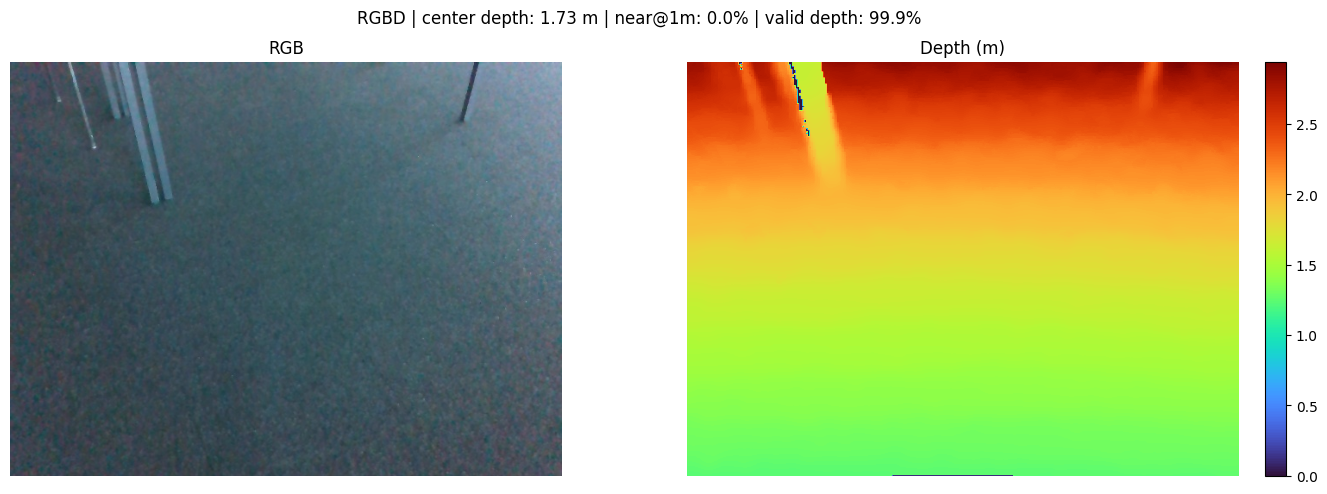

In [3]:
while True:
    rgbd = rob.get_rgbd(timeout=3.0)
    rgb = rgbd["rgb_rgb"]
    depth = rgbd["depth_m"]
    center_depth_m = rgbd["center_depth_m"]
    near_cov = rgbd["near_coverage_1m"]
    valid_fraction = rgbd["valid_depth_fraction"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(rgb)
    axes[0].set_title("RGB")
    axes[0].axis("off")

    depth_img = axes[1].imshow(depth, cmap="turbo")
    axes[1].set_title("Depth (m)")
    axes[1].axis("off")
    fig.colorbar(depth_img, ax=axes[1], fraction=0.046, pad=0.04)

    center_text = "n/a" if center_depth_m is None else f"{center_depth_m:.2f} m"
    near_text = "n/a" if near_cov is None else f"{near_cov * 100.0:.1f}%"
    fig.suptitle(
        f"RGBD | center depth: {center_text} | near@1m: {near_text} | valid depth: {valid_fraction * 100.0:.1f}%"
    )
    fig.tight_layout()
    display(fig)
    plt.close(fig)
    clear_output(wait=True)
    time.sleep(0.1)



KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0xffff953d9790> (for post_execute):


KeyboardInterrupt: 

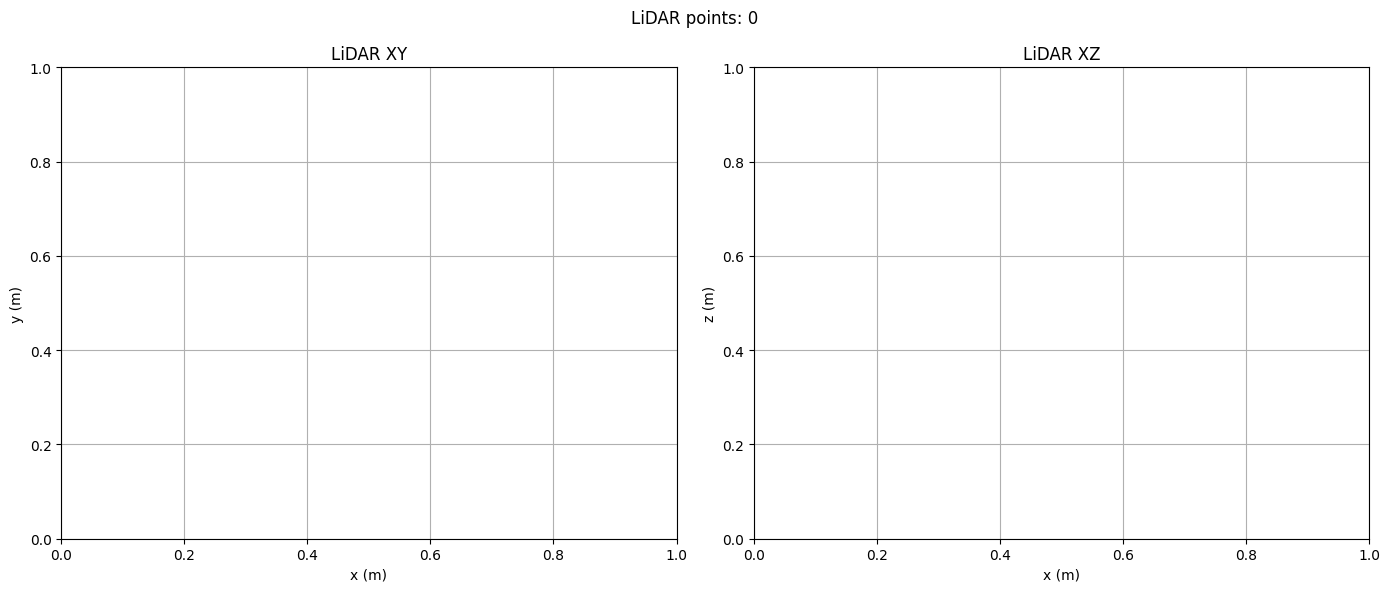

In [4]:
max_points = 15000

while True:
    points = rob.get_lidar_points(max_points=max_points)
    xs = [p["x"] for p in points]
    ys = [p["y"] for p in points]
    zs = [p["z"] for p in points]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    if xs:
        axes[0].scatter(xs, ys, s=1, c=zs, cmap="viridis")
        axes[0].set_aspect("equal", adjustable="box")
        axes[1].scatter(xs, zs, s=1, c=ys, cmap="plasma")
    axes[0].set_title("LiDAR XY")
    axes[0].set_xlabel("x (m)")
    axes[0].set_ylabel("y (m)")
    axes[1].set_title("LiDAR XZ")
    axes[1].set_xlabel("x (m)")
    axes[1].set_ylabel("z (m)")
    fig.suptitle(f"LiDAR points: {len(points)}")
    fig.tight_layout()
    display(fig)
    plt.close(fig)
    clear_output(wait=True)
    time.sleep(0.15)
